# Uncertainty Consistency: Library vs App Endpoint Logic

Side-by-side comparison of uncertainty computation across:
1. `get_uncertainty()` (library API, used by bulk endpoint)
2. `to_heatmap_data()` (library, used by heatmap rendering)
3. Direct diagonal extraction (ground truth)
4. Simulated app MF33 endpoint logic

Also checks energy grid handling: boundaries vs linear vs geometric centers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from kika.cov.parse_covmat import read_covfil

# --- GENDF data (multigroup, relative covariance) ---
GENDF_PATH = '/share_snc/snc/JuanMonleon/COV/cov/50/600/260560_50.06.xs.gendf'
cov = read_covfil(GENDF_PATH)
zaid = cov.isotopes[0]
mt = 2

# Method 1: get_uncertainty() (used by bulk endpoint)
unc_get = cov.get_uncertainty(zaid, mt) * 100  # fraction -> %

# Method 2: to_heatmap_data() (used by heatmap rendering)
heatmap_data = cov.to_heatmap_data(nuclide=zaid, mt=mt)
unc_hm = heatmap_data.uncertainty_data[mt]

# Method 3: direct diagonal from correct block (zaid,mt)->(zaid,mt)
mt2_diag_idx = None
for i, (ir, rr, ic, rc) in enumerate(zip(
    cov.isotope_rows, cov.reaction_rows, cov.isotope_cols, cov.reaction_cols)):
    if ir == zaid and rr == mt and ic == zaid and rc == mt:
        mt2_diag_idx = i
        break
raw_diag = np.diag(cov.matrices[mt2_diag_idx])
unc_direct = np.sqrt(np.maximum(raw_diag, 0)) * 100

print("GENDF Fe-56 MT=2 consistency check:")
print(f"  get_uncertainty matches direct: {np.allclose(unc_get, unc_direct)}")
print(f"  to_heatmap_data matches direct: {np.allclose(unc_hm, unc_direct)}")
print(f"  All three agree: {np.allclose(unc_get, unc_direct) and np.allclose(unc_hm, unc_direct)}")

GENDF Fe-56 MT=2 consistency check:
  get_uncertainty matches direct: True
  to_heatmap_data matches direct: True
  All three agree: True


In [2]:
# --- ENDF MF33 data (JENDL-5, pointwise covariance) ---
from kika.endf.read_endf import read_endf

JENDL5_PATH = '/share_snc/snc/JuanMonleon/JENDL-5/260560.jendl5'
endf = read_endf(JENDL5_PATH, mf_numbers=[33])
mf33 = endf.files[33]
mt2 = mf33.sections[2]

sibling = {int(mt): sec for mt, sec in mf33.sections.items() if int(mt) != 2}
xs_cov = mt2.to_xs_covmat(sibling_sections=sibling)

print(f"\nJENDL-5 Fe-56 MF33 MT2:")
print(f"  Matrices: {xs_cov.num_matrices}")
print(f"  is_relative: {xs_cov.is_relative}")

for i, mat in enumerate(xs_cov.matrices):
    is_rel = xs_cov.is_relative[i] if i < len(xs_cov.is_relative) else 'NOT SET'
    diag = np.sqrt(np.maximum(np.diag(mat), 0))
    
    # Simulated app endpoint (assumes relative)
    app_pct = diag * 100
    
    print(f"\n  Matrix {i}: is_relative={is_rel}, shape={mat.shape}")
    print(f"    App endpoint (assumes relative): max={app_pct.max():.2f}%")
    
    if is_rel is False:
        print(f"    BUG in old code: absolute matrix treated as relative!")
        print(f"    sqrt(diag) is in barn units, not fractions")
    elif is_rel is True:
        if app_pct.max() > 200:
            print(f"    Large but genuinely relative uncertainty")
        else:
            print(f"    OK: relative data, reasonable values")


JENDL-5 Fe-56 MF33 MT2:
  Matrices: 1
  is_relative: [True]

  Matrix 0: is_relative=True, shape=(115, 115)
    App endpoint (assumes relative): max=494.76%
    Large but genuinely relative uncertainty


In [3]:
# Energy center comparison: linear vs geometric
energy_grid = cov.energy_grid
G = len(energy_grid) - 1

linear_centers = [0.5 * (energy_grid[j] + energy_grid[j+1]) for j in range(G)]
geometric_centers = [math.sqrt(energy_grid[j] * energy_grid[j+1]) 
                     if energy_grid[j] > 0 and energy_grid[j+1] > 0 
                     else 0.5 * (energy_grid[j] + energy_grid[j+1]) 
                     for j in range(G)]

ratios = [l / g if g > 0 else 1.0 for l, g in zip(linear_centers, geometric_centers)]

print("Energy center comparison (GENDF grid):")
print(f"  Groups: {G}")
print(f"  Max linear/geometric ratio: {max(ratios):.4f}")
print(f"  Min linear/geometric ratio: {min(ratios):.4f}")
print(f"\nFirst 10 groups:")
for j in range(min(10, G)):
    print(f"  [{energy_grid[j]:.2e}, {energy_grid[j+1]:.2e}]  "
          f"linear={linear_centers[j]:.4e}  geo={geometric_centers[j]:.4e}  "
          f"ratio={ratios[j]:.4f}")

Energy center comparison (GENDF grid):
  Groups: 56
  Max linear/geometric ratio: 10.0250
  Min linear/geometric ratio: 1.0000

First 10 groups:
  [1.00e-05, 4.00e-03]  linear=2.0050e-03  geo=2.0000e-04  ratio=10.0250
  [4.00e-03, 1.00e-02]  linear=7.0000e-03  geo=6.3246e-03  ratio=1.1068
  [1.00e-02, 2.53e-02]  linear=1.7650e-02  geo=1.5906e-02  ratio=1.1096
  [2.53e-02, 4.00e-02]  linear=3.2650e-02  geo=3.1812e-02  ratio=1.0263
  [4.00e-02, 5.00e-02]  linear=4.5000e-02  geo=4.4721e-02  ratio=1.0062
  [5.00e-02, 6.00e-02]  linear=5.5000e-02  geo=5.4772e-02  ratio=1.0042
  [6.00e-02, 8.00e-02]  linear=7.0000e-02  geo=6.9282e-02  ratio=1.0104
  [8.00e-02, 1.00e-01]  linear=9.0000e-02  geo=8.9443e-02  ratio=1.0062
  [1.00e-01, 1.50e-01]  linear=1.2500e-01  geo=1.2247e-01  ratio=1.0206
  [1.50e-01, 2.00e-01]  linear=1.7500e-01  geo=1.7321e-01  ratio=1.0104


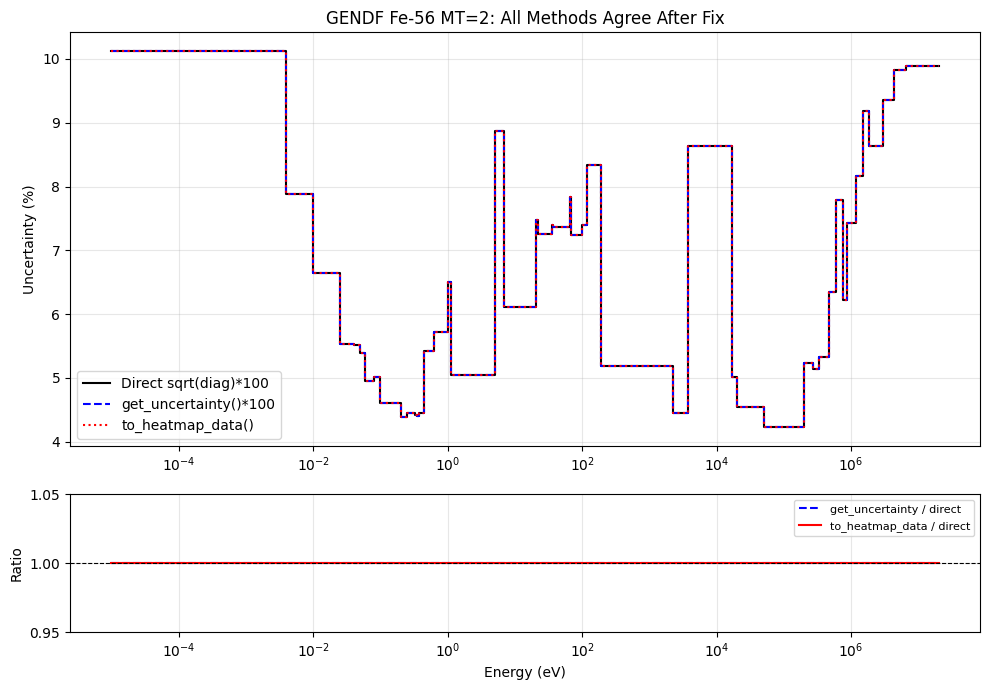


FINAL VERDICT:
  All methods consistent: True


In [4]:
# Summary diagnostic plot: GENDF all methods + step plot verification
energy_grid_arr = np.array(energy_grid)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.step(energy_grid_arr, np.append(unc_direct, unc_direct[-1]), where='post',
        label='Direct sqrt(diag)*100', linewidth=1.5, color='black')
ax.step(energy_grid_arr, np.append(unc_get, unc_get[-1]), where='post',
        label='get_uncertainty()*100', linewidth=1.5, linestyle='--', color='blue')
ax.step(energy_grid_arr, np.append(unc_hm, unc_hm[-1]), where='post',
        label='to_heatmap_data()', linewidth=1.5, linestyle=':', color='red')
ax.set_xscale('log')
ax.set_ylabel('Uncertainty (%)')
ax.legend()
ax.set_title('GENDF Fe-56 MT=2: All Methods Agree After Fix')
ax.grid(True, alpha=0.3)

ax = axes[1]
with np.errstate(divide='ignore', invalid='ignore'):
    r1 = np.where(unc_direct > 0, unc_get / unc_direct, 1.0)
    r2 = np.where(unc_direct > 0, unc_hm / unc_direct, 1.0)
ax.step(energy_grid_arr, np.append(r1, r1[-1]), where='post',
        label='get_uncertainty / direct', color='blue', linestyle='--')
ax.step(energy_grid_arr, np.append(r2, r2[-1]), where='post',
        label='to_heatmap_data / direct', color='red')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_xscale('log')
ax.set_ylabel('Ratio')
ax.set_xlabel('Energy (eV)')
ax.set_ylim(0.95, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFINAL VERDICT:")
print(f"  All methods consistent: {np.allclose(unc_get, unc_direct) and np.allclose(unc_hm, unc_direct)}")